## Spectrogram Generation Pipeline

Build spectrogram PNGs from clipped WAV files using small utility steps so each stage is easy to inspect.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "config.py").exists():
    repo_root = repo_root.parent
if not (repo_root / "src" / "config.py").exists():
    raise FileNotFoundError(f"Couldn't find src/config.py from {Path.cwd()}")

sys.path.insert(0, str(repo_root))

from src.config import CONFIG
from src.dataset.utils.spectrograms import (
    build_spectrogram_index_dataframe,
    collect_capped_non_bird_rows,
    collect_species_clip_rows,
    combine_and_shuffle_clip_rows,
    compute_class_counts,
    generate_spectrogram_pngs_from_index,
    resolve_spectrogram_build_paths,
    write_spectrogram_index_and_errors,
)
from src.dataset.utils.splits import build_default_splits_for_spectrograms


### 1) Resolve Paths and Config


In [2]:
spec_cfg = CONFIG.spectrogram
train_shape_hw = spec_cfg.train_out_shape_hw

paths = resolve_spectrogram_build_paths(
    out_name="spectrograms",
    train_shape_hw=train_shape_hw,
)

print("DATA_DIR:", paths.data_dir)
print("SPECIES_ROOT:", paths.species_root)
print("NON_BIRD_ROOT:", paths.non_bird_root)
print("FULL_DIR:", paths.full_dir)
print("TRAIN_DIR:", paths.train_dir)


DATA_DIR: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data
SPECIES_ROOT: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/clips/species
NON_BIRD_ROOT: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/clips/non_bird
FULL_DIR: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/full
TRAIN_DIR: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/train_64x128


### 2) Collect Clip Rows


In [3]:
non_bird_cap = 1000
seed = CONFIG.preprocessing.seed

species_rows = collect_species_clip_rows(paths.species_root)
non_bird_rows = collect_capped_non_bird_rows(
    paths.non_bird_root,
    non_bird_cap=non_bird_cap,
    seed=seed,
)
clip_rows = combine_and_shuffle_clip_rows(species_rows, non_bird_rows, seed=seed)

print("Species rows:", len(species_rows))
print("Non-bird rows:", len(non_bird_rows))
print("Total rows:", len(clip_rows))
clip_rows[:3]


Species rows: 29201
Non-bird rows: 1000
Total rows: 30201


[{'wav_path': '/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/clips/species/cuculus_canorus/XC281233__s40000__e43000.wav',
  'class_name': 'cuculus_canorus',
  'source': 'species'},
 {'wav_path': '/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/clips/species/falco_peregrinus/XC1042709__s22000__e25000.wav',
  'class_name': 'falco_peregrinus',
  'source': 'species'},
 {'wav_path': '/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/clips/species/pica_pica/XC59766__s7000__e10000.wav',
  'class_name': 'pica_pica',
  'source': 'species'}]

### 3) Build Index DataFrame with Output Paths


In [4]:
index_df = build_spectrogram_index_dataframe(
    clip_rows,
    full_dir=paths.full_dir,
    train_dir=paths.train_dir,
)

print(index_df.shape)
index_df.head()


(30201, 6)


,wav_path,class_name,source,clip_id,full_png,train_png
0,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,cuculus_canorus,species,XC281233__s40000__e43000,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...
1,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,falco_peregrinus,species,XC1042709__s22000__e25000,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...
2,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,pica_pica,species,XC59766__s7000__e10000,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...
3,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,fringilla_coelebs,species,XC788733__s1000__e4000,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...
4,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,saxicola_rubicola,species,XC919538__s1000__e4000,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...,/Users/justyna-przy/Projects/ISE/FYP/src/bird_...


### 4) Generate Spectrogram PNGs


In [5]:
errors = generate_spectrogram_pngs_from_index(
    index_df,
    spec_cfg=spec_cfg,
    save_full=True,
    overwrite=False,
)

print("Generation errors:", len(errors))
if errors:
    errors[:5]


Generating spectrograms: 100%|██████████| 30201/30201 [01:13<00:00, 411.67it/s]

Generation errors: 0


### 5) Write Index and Plot Class Counts


Wrote index: /Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/index_train_64x128.csv
class_name
non_bird                      1000
fringilla_coelebs              843
erithacus_rubecula             818
sylvia_atricapilla             817
troglodytes_troglodytes        816
parus_major                    785
phylloscopus_collybita         776
cyanistes_caeruleus            769
periparus_ater                 767
prunella_modularis             743
cuculus_canorus                739
carduelis_carduelis            725
saxicola_rubicola              720
phylloscopus_trochilus         718
coloeus_monedula               715
aegithalos_caudatus            692
acrocephalus_schoenobaenus     675
columba_palumbus               668
buteo_buteo                    665
turdus_merula                  659
chloris_chloris                655
streptopelia_decaocto          650
emberiza_citrinella            633
corvus_corax                   632
pica_pica                      628
hirundo_rustic

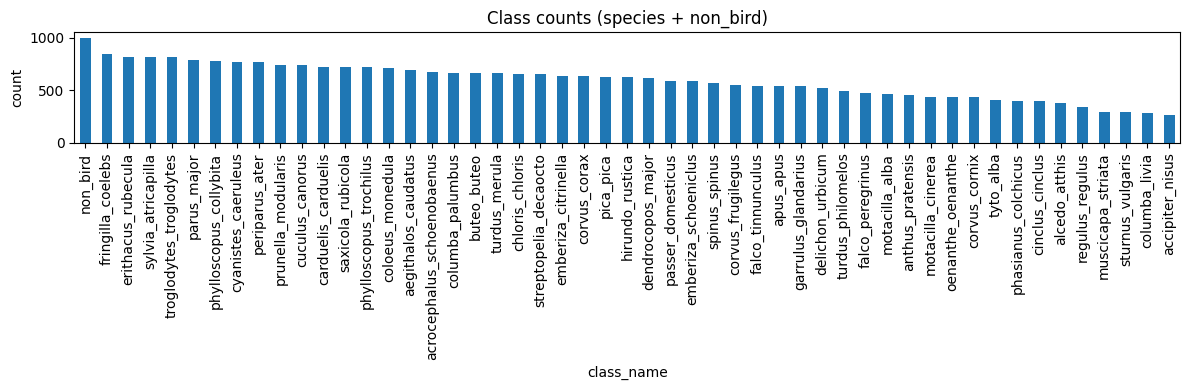

In [6]:
index_csv = write_spectrogram_index_and_errors(
    index_df,
    out_root=paths.out_root,
    train_shape_hw=train_shape_hw,
    errors=errors,
)

print("Wrote index:", index_csv)

class_counts = compute_class_counts(index_df)
print(class_counts)

plt.figure(figsize=(12, 4))
class_counts.plot(kind="bar")
plt.title("Class counts (species + non_bird)")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### 6) Build Splits


In [7]:
split_paths = build_default_splits_for_spectrograms()
split_paths


{'train': PosixPath('/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/splits/train.csv'),
 'val': PosixPath('/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/splits/val.csv'),
 'test': PosixPath('/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/splits/test.csv'),
 'classes': PosixPath('/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/splits/classes.json'),
 'info': PosixPath('/Users/justyna-przy/Projects/ISE/FYP/src/bird_data/spectrograms/splits/split_info.json')}